# 🔨 Violence Detection — Custom CNN + GRU **From Scratch**
### Professional Notebook | Explainable AI + Detailed Evaluation



## 📋 Table of Contents
1. [Setup & Imports](#1)
2. [Configuration](#2)
3. [Dataset & DataLoaders](#3)
4. [Architecture — Custom CNN + BiGRU](#4)
5. [Training](#5)
6. [Evaluation & Metrics](#6)
7. [Explainable AI — Grad-CAM](#7)
8. [Save Model](#8)

<a id='1'></a>
## 1.  Setup & Imports

In [1]:
!pip install grad-cam scikit-learn matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import cv2
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print(f"✅ All imports OK")
print(f"🐍 PyTorch : {torch.__version__}")
print(f"💻 CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮 GPU     : {torch.cuda.get_device_name(0)}")

✅ All imports OK
🐍 PyTorch : 2.10.0+cu128
💻 CUDA    : True
🎮 GPU     : Tesla T4


<a id='2'></a>
## 2.  Configuration

In [3]:
CFG = {
    # Data
    "root_dir"    : "/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset",
    "num_frames"  : 16,
    "img_size"    : 112,       # 112×112 — adapté au CNN from scratch (vs 224 pour ResNet)
    "train_ratio" : 0.8,

    # CNN from scratch
    "cnn_channels": [3, 32, 64, 128, 256, 512],   # progression des feature maps
    "feature_dim" : 512,       # sortie du CNN après global avg pool

    # GRU
    "hidden_size" : 256,
    "gru_layers"  : 2,
    "dropout"     : 0.3,
    "fc_dropout"  : 0.5,

    # Training  — from scratch nécessite plus d'epochs
    "epochs"      : 50,
    "batch_size"  : 16,
    "lr"          : 3e-4,      # plus haut que fine-tuning
    "weight_decay": 1e-4,
    "label_smooth": 0.1,
    "patience"    : 12,        # plus de patience — le modèle apprend de zéro
    "num_workers" : 4,
    "warmup_epochs": 5,        # warmup LR les 5 premières epochs

    # Save
    "model_path"  : "model_scratch.pth",
    "history_path": "training_history_scratch.json",

    # Labels
    "classes"     : ["NonViolence", "Violence"],
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device    : {DEVICE}")
print(f"📐 Image size : {CFG['img_size']}×{CFG['img_size']}")
print(f"💾 Saved as   : {CFG['model_path']}")

🖥️  Device    : cuda
📐 Image size : 112×112
💾 Saved as   : model_scratch.pth


<a id='3'></a>
## 3.  Dataset & DataLoaders

> From scratch → on utilise **plus d'augmentation** pour compenser l'absence de préentraînement.

In [4]:
# ── Normalisation ImageNet non nécessaire (pas de pretrained)
# ── On normalise sur [0,1] puis centre sur 0.5
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])


class ViolenceDataset(Dataset):
    def __init__(self, root_dir, num_frames=16, transform=None):
        self.paths      = []
        self.labels     = []
        self.num_frames = num_frames
        self.transform  = transform

        for label_name in ["Violence", "NonViolence"]:
            folder = os.path.join(root_dir, label_name)
            for file in os.listdir(folder):
                if file.endswith(".mp4"):
                    self.paths.append(os.path.join(folder, file))
                    self.labels.append(1 if label_name == "Violence" else 0)

        print(f"📁 Dataset : {len(self.paths)} videos")
        v  = sum(self.labels)
        nv = len(self.labels) - v
        print(f"   ├─ Violence    : {v}")
        print(f"   └─ NonViolence : {nv}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        frames = self._load_frames(self.paths[idx])
        if frames is None:
            idx    = (idx + 1) % len(self.paths)
            frames = self._load_frames(self.paths[idx])
        t      = self.transform or train_transform
        frames = torch.stack([t(f) for f in frames])
        label  = torch.tensor(self.labels[idx]).long()
        return frames, label

    def _load_frames(self, path):
        cap     = cv2.VideoCapture(path)
        frames  = []
        total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = set(np.linspace(0, total - 1, self.num_frames).astype(int)) if total > 0 else None
        i = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if indices is None or i in indices:
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            i += 1
        cap.release()
        if not frames:
            return None
        while len(frames) < self.num_frames:
            frames.append(frames[-1])
        return frames


full_dataset = ViolenceDataset(CFG["root_dir"], CFG["num_frames"])
train_size   = int(CFG["train_ratio"] * len(full_dataset))
val_size     = len(full_dataset) - train_size

train_ds, val_ds = random_split(full_dataset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))
val_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True, persistent_workers=True)

print(f"\n🔀 Train : {len(train_ds)} | Val : {len(val_ds)}")

📁 Dataset : 1951 videos
   ├─ Violence    : 1000
   └─ NonViolence : 951

🔀 Train : 1560 | Val : 391


<a id='4'></a>
## 4.  Architecture — Custom CNN + BiGRU From Scratch

```
Input video  (B, T=16, 3, 112, 112)
       │
       ▼  per-frame  (B×T, 3, 112, 112)
┌──────────────────────────────────┐
│      CUSTOM CNN BACKBONE         │
│                                  │
│  ConvBlock(3  → 32)  56×56       │
│  ConvBlock(32 → 64)  28×28       │
│  ConvBlock(64 → 128) 14×14       │
│  ConvBlock(128→ 256)  7×7        │
│  ConvBlock(256→ 512)  4×4        │
│  GlobalAvgPool  → (B×T, 512)     │
└──────────────────────────────────┘
       │  reshape → (B, T, 512)
       ▼
  BiGRU  (2 layers, hidden=256)
       │  last hidden → (B, 512)
       ▼
  FC: 512 → 128 → 2
       │
       ▼
  Logits  (B, 2)
```

**ConvBlock** = `Conv2d → BatchNorm2d → ReLU → MaxPool2d`  
**Init** = He (Kaiming) pour toutes les couches conv et linéaires

In [5]:
# ══════════════════════════════════════════════════════════════════════════
#  Building block
# ══════════════════════════════════════════════════════════════════════════
class ConvBlock(nn.Module):
    """
    Conv2d(3×3) → BatchNorm2d → ReLU → MaxPool2d(2×2)
    Halves spatial dims at each stage.
    """
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# ══════════════════════════════════════════════════════════════════════════
#  Full model — 100% from scratch
# ══════════════════════════════════════════════════════════════════════════
class ViolenceModelScratch(nn.Module):
    """
    Custom CNN (5 ConvBlocks) + Bidirectional GRU.
    Zéro poids pré-entraînés — tout est initialisé from scratch.
    """
    def __init__(self, cfg):
        super().__init__()

        ch = cfg["cnn_channels"]  # [3, 32, 64, 128, 256, 512]

        # ── CNN backbone ──────────────────────────────────────────────────
        # 112 → 56 → 28 → 14 → 7 → 4  (après 5 MaxPool)
        self.cnn = nn.Sequential(
            ConvBlock(ch[0], ch[1]),   # 112 → 56
            ConvBlock(ch[1], ch[2]),   # 56  → 28
            ConvBlock(ch[2], ch[3]),   # 28  → 14
            ConvBlock(ch[3], ch[4]),   # 14  → 7
            ConvBlock(ch[4], ch[5]),   # 7   → 4  (dernière couche = cible Grad-CAM)
            nn.AdaptiveAvgPool2d(1),   # (B*T, 512, 1, 1)
        )

        # ── Temporal BiGRU ────────────────────────────────────────────────
        self.gru = nn.GRU(
            input_size    = cfg["feature_dim"],   # 512
            hidden_size   = cfg["hidden_size"],   # 256
            num_layers    = cfg["gru_layers"],
            dropout       = cfg["dropout"],
            batch_first   = True,
            bidirectional = True
        )

        # ── Classifier ───────────────────────────────────────────────────
        self.fc = nn.Sequential(
            nn.Linear(cfg["hidden_size"] * 2, 128),   # 512 → 128
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(cfg["fc_dropout"]),
            nn.Linear(128, 2)
        )

        # ── He (Kaiming) initialization ───────────────────────────────────
        self._init_weights()

    def _init_weights(self):
        """He init for conv/linear, constant for BN."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        # GRU — orthogonal init for recurrent weights
        for name, p in self.gru.named_parameters():
            if 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.constant_(p, 0)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        x = self.cnn(x)                        # (B*T, 512, 1, 1)
        x = x.view(B, T, -1)                   # (B, T, 512)
        _, h = self.gru(x)                     # h: (layers*2, B, 256)
        h = torch.cat((h[-2], h[-1]), dim=1)   # (B, 512)
        return self.fc(h)                      # (B, 2)


model = ViolenceModelScratch(CFG).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🔢 Total params     : {total_params:,}")
print(f"✏️  Trainable params : {trainable_params:,}  (100% — from scratch)")
print()
print("📐 Architecture summary")
print(f"  CNN     : 5 × ConvBlock  (double conv + BN + ReLU + MaxPool)")
print(f"  Output  : AdaptiveAvgPool → {CFG['feature_dim']} features")
print(f"  GRU     : {CFG['gru_layers']} layers, hidden={CFG['hidden_size']}, bidirectional → {CFG['hidden_size']*2}")
print(f"  FC      : {CFG['hidden_size']*2} → 128 → 2")
print(f"  Init    : He (conv/linear) + Orthogonal (GRU recurrent)")

🔢 Total params     : 7,145,826
✏️  Trainable params : 7,145,826  (100% — from scratch)

📐 Architecture summary
  CNN     : 5 × ConvBlock  (double conv + BN + ReLU + MaxPool)
  Output  : AdaptiveAvgPool → 512 features
  GRU     : 2 layers, hidden=256, bidirectional → 512
  FC      : 512 → 128 → 2
  Init    : He (conv/linear) + Orthogonal (GRU recurrent)


<a id='5'></a>
## 5.  Training

> **From scratch tips appliqués :**
> - 50 epochs (vs 25) — le modèle part de zéro
> - LR warmup linéaire sur 5 epochs
> - Cosine Annealing après le warmup
> - Patience plus haute (12)

In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smooth"])

optimizer = torch.optim.AdamW(
    model.parameters(),        # tous les params entraînables
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

# ── LR Warmup + Cosine Annealing ──────────────────────────────────────────
def warmup_cosine(epoch):
    W = CFG["warmup_epochs"]
    E = CFG["epochs"]
    if epoch < W:
        return (epoch + 1) / W                  # linéaire 0 → 1
    else:
        t = (epoch - W) / (E - W)
        return 0.5 * (1 + np.cos(np.pi * t))    # cosine 1 → 0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)
scaler    = torch.amp.GradScaler('cuda')

history = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : [],
    "lr"        : []
}

best_val_acc = 0.0
patience_ctr = 0

# ═══════════════════════════════════════════════════
#  Training Loop
# ═══════════════════════════════════════════════════
for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────
    model.train()
    tr_loss = tr_correct = tr_total = 0

    for i, (frames, labels) in enumerate(train_loader):
        frames, labels = frames.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(frames)
            loss = criterion(out, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        tr_loss    += loss.item() * labels.size(0)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

        if i % 10 == 0:
            print(f"  Epoch {epoch:02d} | Batch {i:3d}/{len(train_loader)} | Loss {loss.item():.4f}", end="\r")

    train_loss = tr_loss / tr_total
    train_acc  = tr_correct / tr_total

    # ── Validation ─────────────────────────────────
    model.eval()
    vl_loss = vl_correct = vl_total = 0

    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                out  = model(frames)
                loss = criterion(out, labels)
            vl_loss    += loss.item() * labels.size(0)
            vl_correct += (out.argmax(1) == labels).sum().item()
            vl_total   += labels.size(0)

    val_loss = vl_loss / vl_total
    val_acc  = vl_correct / vl_total

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["train_acc" ].append(train_acc)
    history["val_loss"  ].append(val_loss)
    history["val_acc"   ].append(val_acc)
    history["lr"        ].append(current_lr)

    tag = "🔥 WARMUP" if epoch <= CFG["warmup_epochs"] else ""
    print(f"Epoch {epoch:02d}/{CFG['epochs']} | "
          f"Train {train_loss:.4f}/{train_acc:.4f} | "
          f"Val {val_loss:.4f}/{val_acc:.4f} | "
          f"LR {current_lr:.2e} | {time.time()-t0:.1f}s {tag}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save(model.state_dict(), CFG["model_path"])
        print(f"  💾 Saved model_scratch  (val_acc={best_val_acc:.4f})")
    else:
        patience_ctr += 1
        print(f"  ⚠️  No improvement ({patience_ctr}/{CFG['patience']})")
        if patience_ctr >= CFG["patience"]:
            print("  ⛔ Early stopping")
            break

with open(CFG["history_path"], "w") as f:
    json.dump(history, f)

print(f"\n🏆 Best Val Accuracy : {best_val_acc:.4f}")

[h264 @ 0x3e741140] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3e741140] error while decoding MB 98 31


Epoch 01/50 | Train 0.8998/0.5782 | Val 0.5552/0.7136 | LR 1.20e-04 | 260.3s 🔥 WARMUP
  💾 Saved model_scratch  (val_acc=0.7136)


[h264 @ 0x3e098a80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3e098a80] error while decoding MB 98 31


Epoch 02/50 | Train 0.7775/0.6712 | Val 0.6634/0.7698 | LR 1.80e-04 | 255.7s 🔥 WARMUP
  💾 Saved model_scratch  (val_acc=0.7698)


[h264 @ 0x3e79ce40] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3e79ce40] error while decoding MB 98 31


...

Epoch 43/50 | Train 0.2188/0.9981 | Val 0.2821/0.9565 | LR 1.76e-05 | 234.3s 
  ⚠️  No improvement (10/12)


[h264 @ 0x3e02d440] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3e02d440] error while decoding MB 98 31


Epoch 44/50 | Train 0.2198/0.9962 | Val 0.2769/0.9642 | LR 1.30e-05 | 243.0s 
  ⚠️  No improvement (11/12)


[h264 @ 0x3e014440] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3e014440] error while decoding MB 98 31


Epoch 45/50 | Train 0.2201/0.9981 | Val 0.2786/0.9642 | LR 9.05e-06 | 249.9s 
  ⚠️  No improvement (12/12)
  ⛔ Early stopping

🏆 Best Val Accuracy : 0.9744


<a id='6'></a>
## 6. Evaluation — Curves & Metrics

In [7]:
model.load_state_dict(torch.load(CFG["model_path"], map_location=DEVICE))
model.eval()
print(f"✅ Loaded best model : {CFG['model_path']}")

✅ Loaded best model : model_scratch.pth


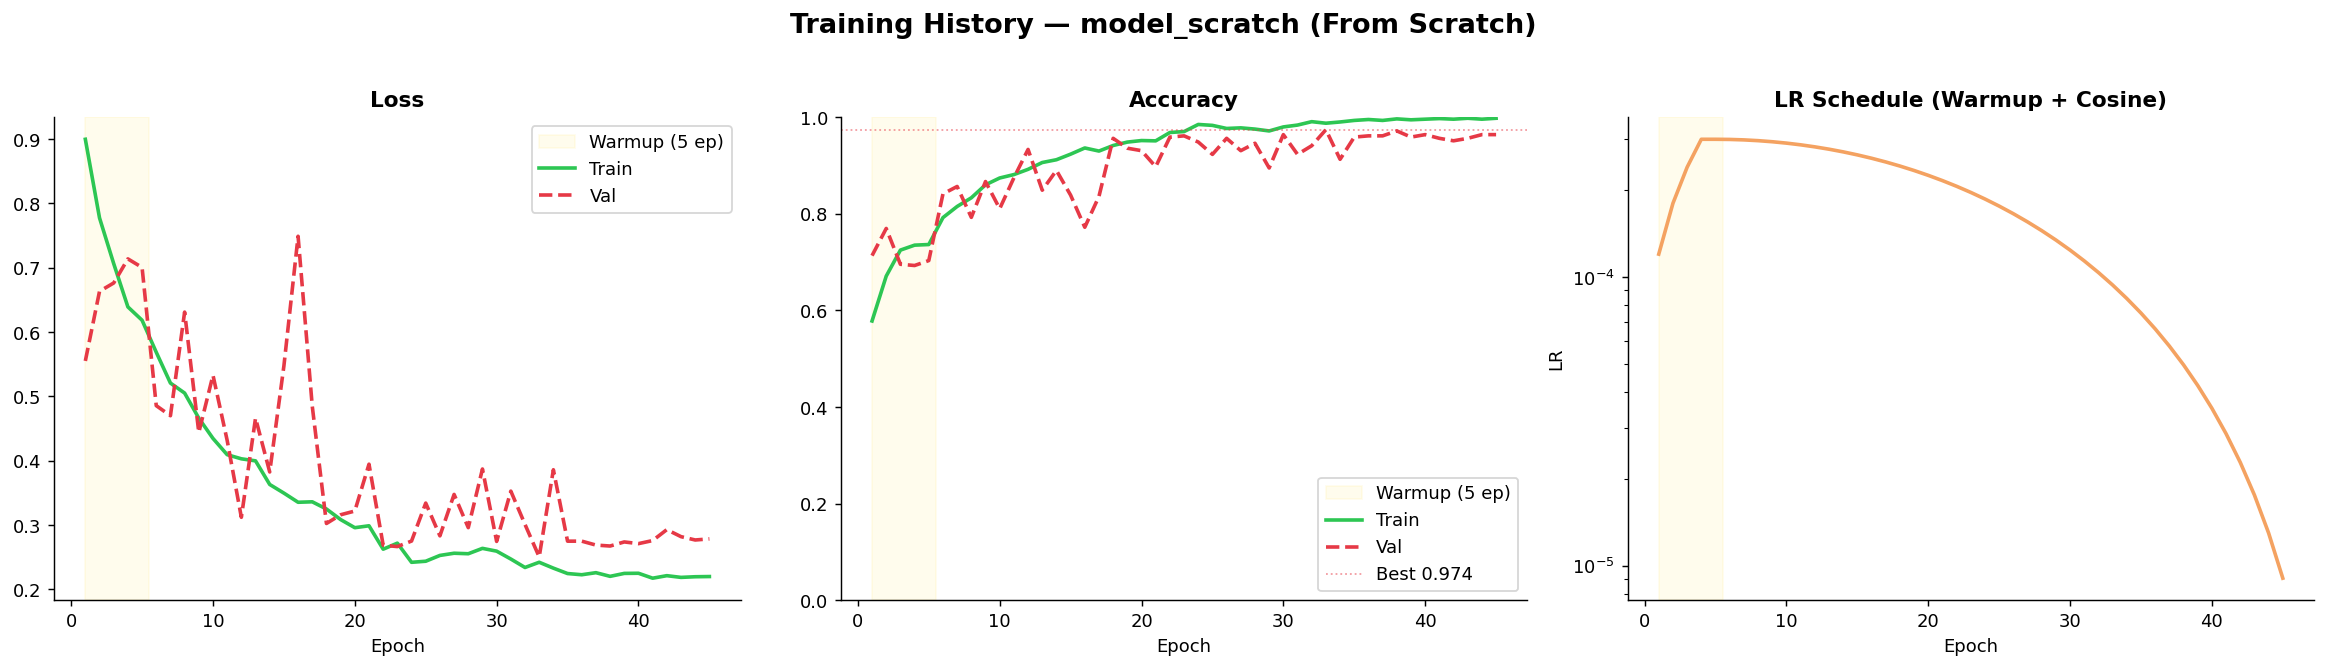

In [8]:
# ══════════════════════════════════════════════════════════════════════════
#  6.1 — Training Curves (avec zone warmup)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History — model_scratch (From Scratch)",
             fontsize=15, fontweight='bold', y=1.02)

ep     = range(1, len(history["train_loss"]) + 1)
colors = {"train": "#2DC653", "val": "#E63946", "lr": "#F4A261"}
W      = CFG["warmup_epochs"]

for ax, metric, title in zip(
    axes[:2],
    [("train_loss", "val_loss"), ("train_acc", "val_acc")],
    ["Loss", "Accuracy"]
):
    ax.axvspan(1, W + 0.5, alpha=0.07, color='gold', label=f"Warmup ({W} ep)")
    ax.plot(ep, history[metric[0]], color=colors["train"], lw=2, label=f"Train")
    ax.plot(ep, history[metric[1]], color=colors["val"],   lw=2, label=f"Val", linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.legend()
    if title == "Accuracy":
        ax.set_ylim(0, 1)
        ax.axhline(max(history["val_acc"]), color=colors["val"],
                   lw=1, linestyle=':', alpha=0.5,
                   label=f"Best {max(history['val_acc']):.3f}")
        ax.legend()

axes[2].plot(ep, history["lr"], color=colors["lr"], lw=2)
axes[2].axvspan(1, W + 0.5, alpha=0.07, color='gold')
axes[2].set_title("LR Schedule (Warmup + Cosine)", fontweight='bold')
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig("training_curves_scratch.png", bbox_inches='tight')
plt.show()

In [9]:
# ══════════════════════════════════════════════════════════════════════════
#  6.2 — Collect predictions
# ══════════════════════════════════════════════════════════════════════════
all_preds = []; all_labels = []; all_probs = []

with torch.no_grad():
    for frames, labels in val_loader:
        frames = frames.to(DEVICE)
        with torch.amp.autocast('cuda'):
            out = model(frames)
        all_probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Collected {len(all_labels)} samples")

Collected 391 samples


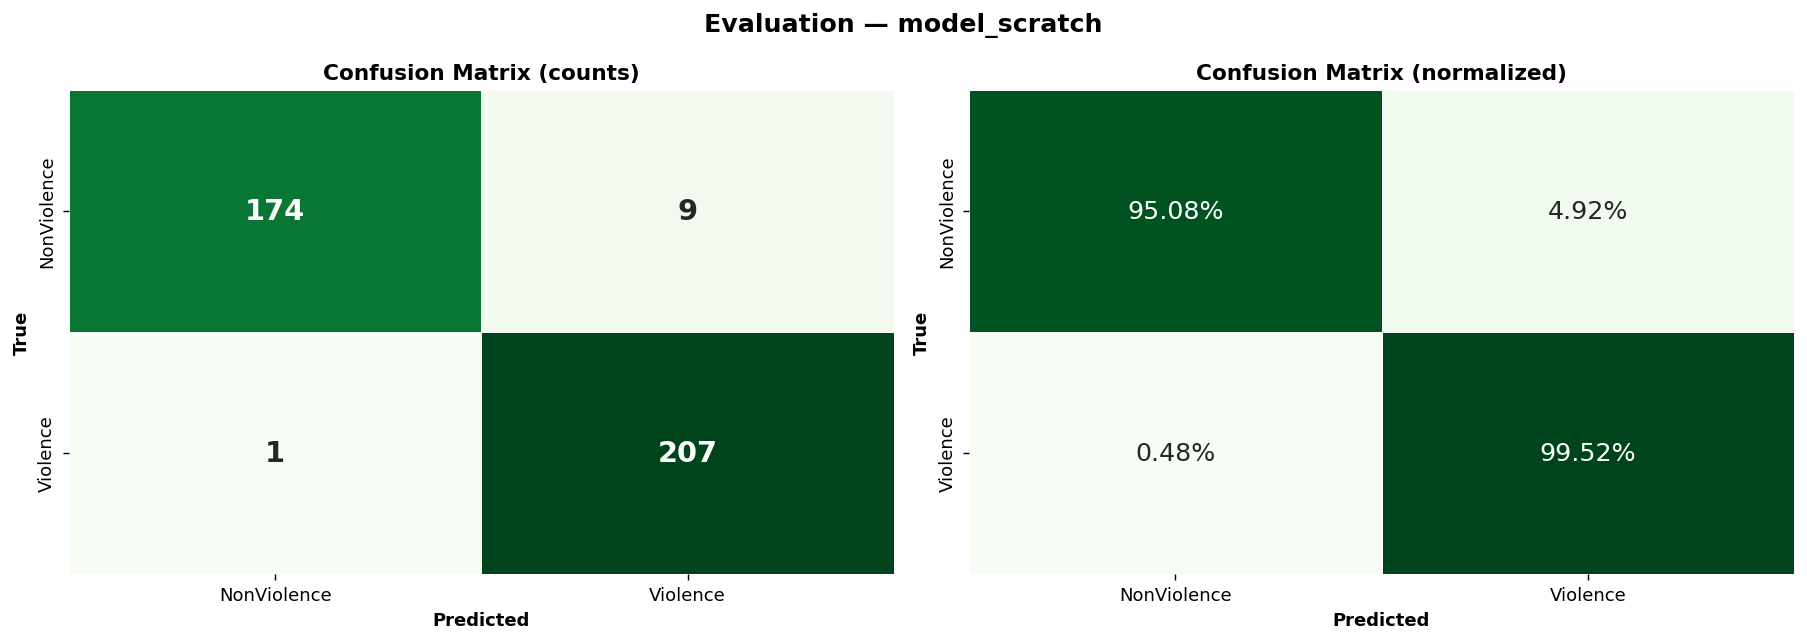


═══════════════════════════════════════════════════════
  CLASSIFICATION REPORT — From Scratch
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

 NonViolence     0.9943    0.9508    0.9721       183
    Violence     0.9583    0.9952    0.9764       208

    accuracy                         0.9744       391
   macro avg     0.9763    0.9730    0.9742       391
weighted avg     0.9752    0.9744    0.9744       391

  AUC-ROC     : 0.9906
  AUC-PR      : 0.9866
  Sensitivity : 0.9952
  Specificity : 0.9508
═══════════════════════════════════════════════════════


In [10]:
# ══════════════════════════════════════════════════════════════════════════
#  6.3 — Confusion Matrix
# ══════════════════════════════════════════════════════════════════════════
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluation — model_scratch", fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CFG["classes"], yticklabels=CFG["classes"],
            ax=axes[0], linewidths=.5, cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title("Confusion Matrix (counts)", fontweight='bold')
axes[0].set_xlabel("Predicted", fontweight='bold')
axes[0].set_ylabel("True", fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CFG["classes"], yticklabels=CFG["classes"],
            ax=axes[1], linewidths=.5, cbar=False,
            annot_kws={"size": 14})
axes[1].set_title("Confusion Matrix (normalized)", fontweight='bold')
axes[1].set_xlabel("Predicted", fontweight='bold')
axes[1].set_ylabel("True", fontweight='bold')

plt.tight_layout()
plt.savefig("confusion_matrix_scratch.png", bbox_inches='tight')
plt.show()

print("\n" + "═"*55)
print("  CLASSIFICATION REPORT — From Scratch")
print("═"*55)
print(classification_report(all_labels, all_preds,
                             target_names=CFG["classes"], digits=4))

tn, fp, fn, tp = cm.ravel()
auc_roc = roc_auc_score(all_labels, all_probs)
auc_pr  = average_precision_score(all_labels, all_probs)
print(f"  AUC-ROC     : {auc_roc:.4f}")
print(f"  AUC-PR      : {auc_pr:.4f}")
print(f"  Sensitivity : {tp/(tp+fn):.4f}")
print(f"  Specificity : {tn/(tn+fp):.4f}")
print("═"*55)

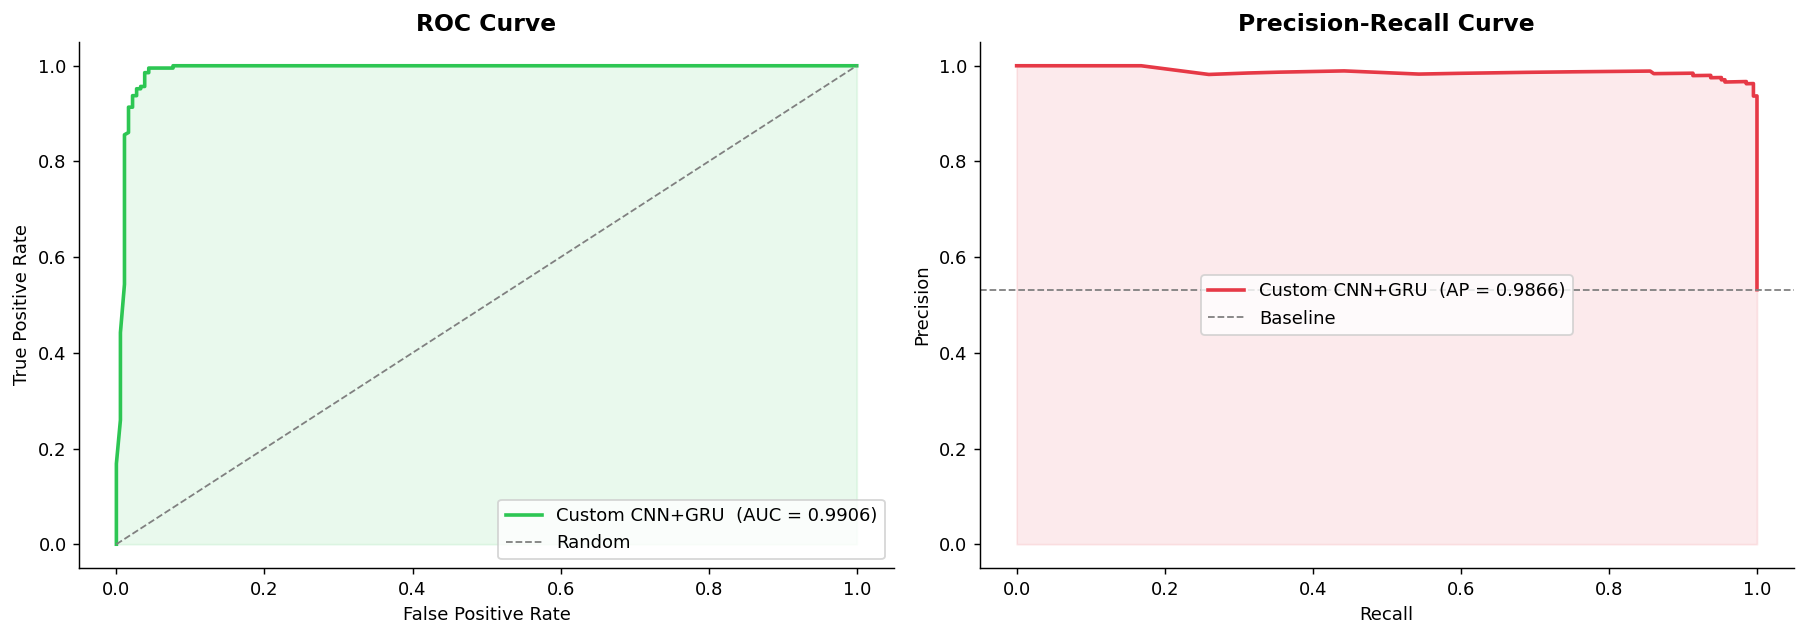

In [11]:
# ══════════════════════════════════════════════════════════════════════════
#  6.4 — ROC & PR Curves
# ══════════════════════════════════════════════════════════════════════════
fpr, tpr, _  = roc_curve(all_labels, all_probs)
prec, rec, _ = precision_recall_curve(all_labels, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#2DC653', lw=2,
             label=f"Custom CNN+GRU  (AUC = {auc_roc:.4f})")
axes[0].plot([0,1],[0,1], color='gray', lw=1, linestyle='--', label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2DC653')
axes[0].set_title("ROC Curve", fontweight='bold', fontsize=13)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc='lower right')

axes[1].plot(rec, prec, color='#E63946', lw=2,
             label=f"Custom CNN+GRU  (AP = {auc_pr:.4f})")
axes[1].axhline(all_labels.mean(), color='gray', lw=1, linestyle='--', label='Baseline')
axes[1].fill_between(rec, prec, alpha=0.1, color='#E63946')
axes[1].set_title("Precision-Recall Curve", fontweight='bold', fontsize=13)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.savefig("roc_pr_scratch.png", bbox_inches='tight')
plt.show()

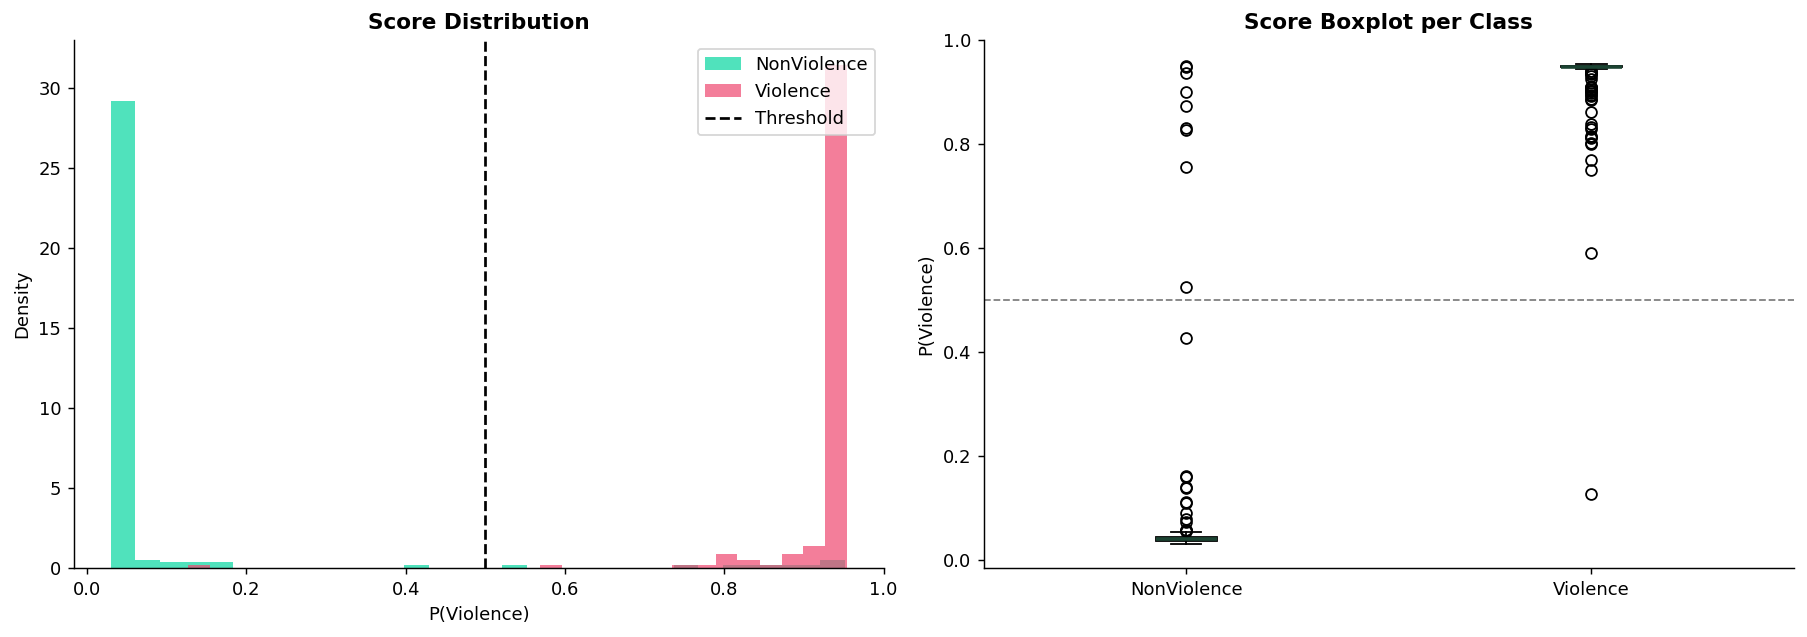

In [12]:
# ══════════════════════════════════════════════════════════════════════════
#  6.5 — Confidence Distribution
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

v_probs  = all_probs[all_labels == 1]
nv_probs = all_probs[all_labels == 0]

axes[0].hist(nv_probs, bins=30, alpha=0.7, color='#06D6A0', label='NonViolence', density=True)
axes[0].hist(v_probs,  bins=30, alpha=0.7, color='#EF476F', label='Violence',    density=True)
axes[0].axvline(0.5, color='black', lw=1.5, linestyle='--', label='Threshold')
axes[0].set_title("Score Distribution", fontweight='bold')
axes[0].set_xlabel("P(Violence)")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].boxplot([nv_probs, v_probs], labels=['NonViolence', 'Violence'],
                patch_artist=True,
                boxprops=dict(facecolor='#B7E4C7', color='black'),
                medianprops=dict(color='#1B4332', lw=2))
axes[1].axhline(0.5, color='gray', lw=1, linestyle='--')
axes[1].set_title("Score Boxplot per Class", fontweight='bold')
axes[1].set_ylabel("P(Violence)")

plt.tight_layout()
plt.savefig("confidence_distribution_scratch.png", bbox_inches='tight')
plt.show()

<a id='7'></a>
## 7.  Explainable AI — Grad-CAM

**Pourquoi Grad-CAM est particulièrement intéressant from scratch ?**  
Contrairement à ResNet18/50 qui ont des features pré-structurés, ici le CNN a appris **ses propres représentations** sur le dataset violence. Les heatmaps montrent ce que le modèle a réellement appris à détecter — souvent des patterns de mouvement, silhouettes, et zones de contact physique.

In [13]:
# ── La cible Grad-CAM = dernier ConvBlock avant AdaptiveAvgPool
# ── model.cnn[-2] = ConvBlock(256→512) = cnn[4]

class CNNWrapper(nn.Module):
    """Expose uniquement le CNN pour Grad-CAM (single frame)."""
    def __init__(self, full_model):
        super().__init__()
        self.cnn = full_model.cnn

    def forward(self, x):
        return self.cnn(x).squeeze(-1).squeeze(-1)   # (B, 512)


cnn_wrapper  = CNNWrapper(model).to(DEVICE)
cnn_wrapper.eval()

# ConvBlock[-1].block[-1] = dernier ReLU de la dernière double conv
# On cible le ConvBlock 4 (index 4 dans model.cnn)
target_layer = [model.cnn[4].block[-1]]   # ReLU du 5ème ConvBlock

cam = GradCAM(model=cnn_wrapper, target_layers=target_layer)
print("✅ Grad-CAM : ConvBlock[4] → ReLU (dernière activation spatiale)")

✅ Grad-CAM : ConvBlock[4] → ReLU (dernière activation spatiale)


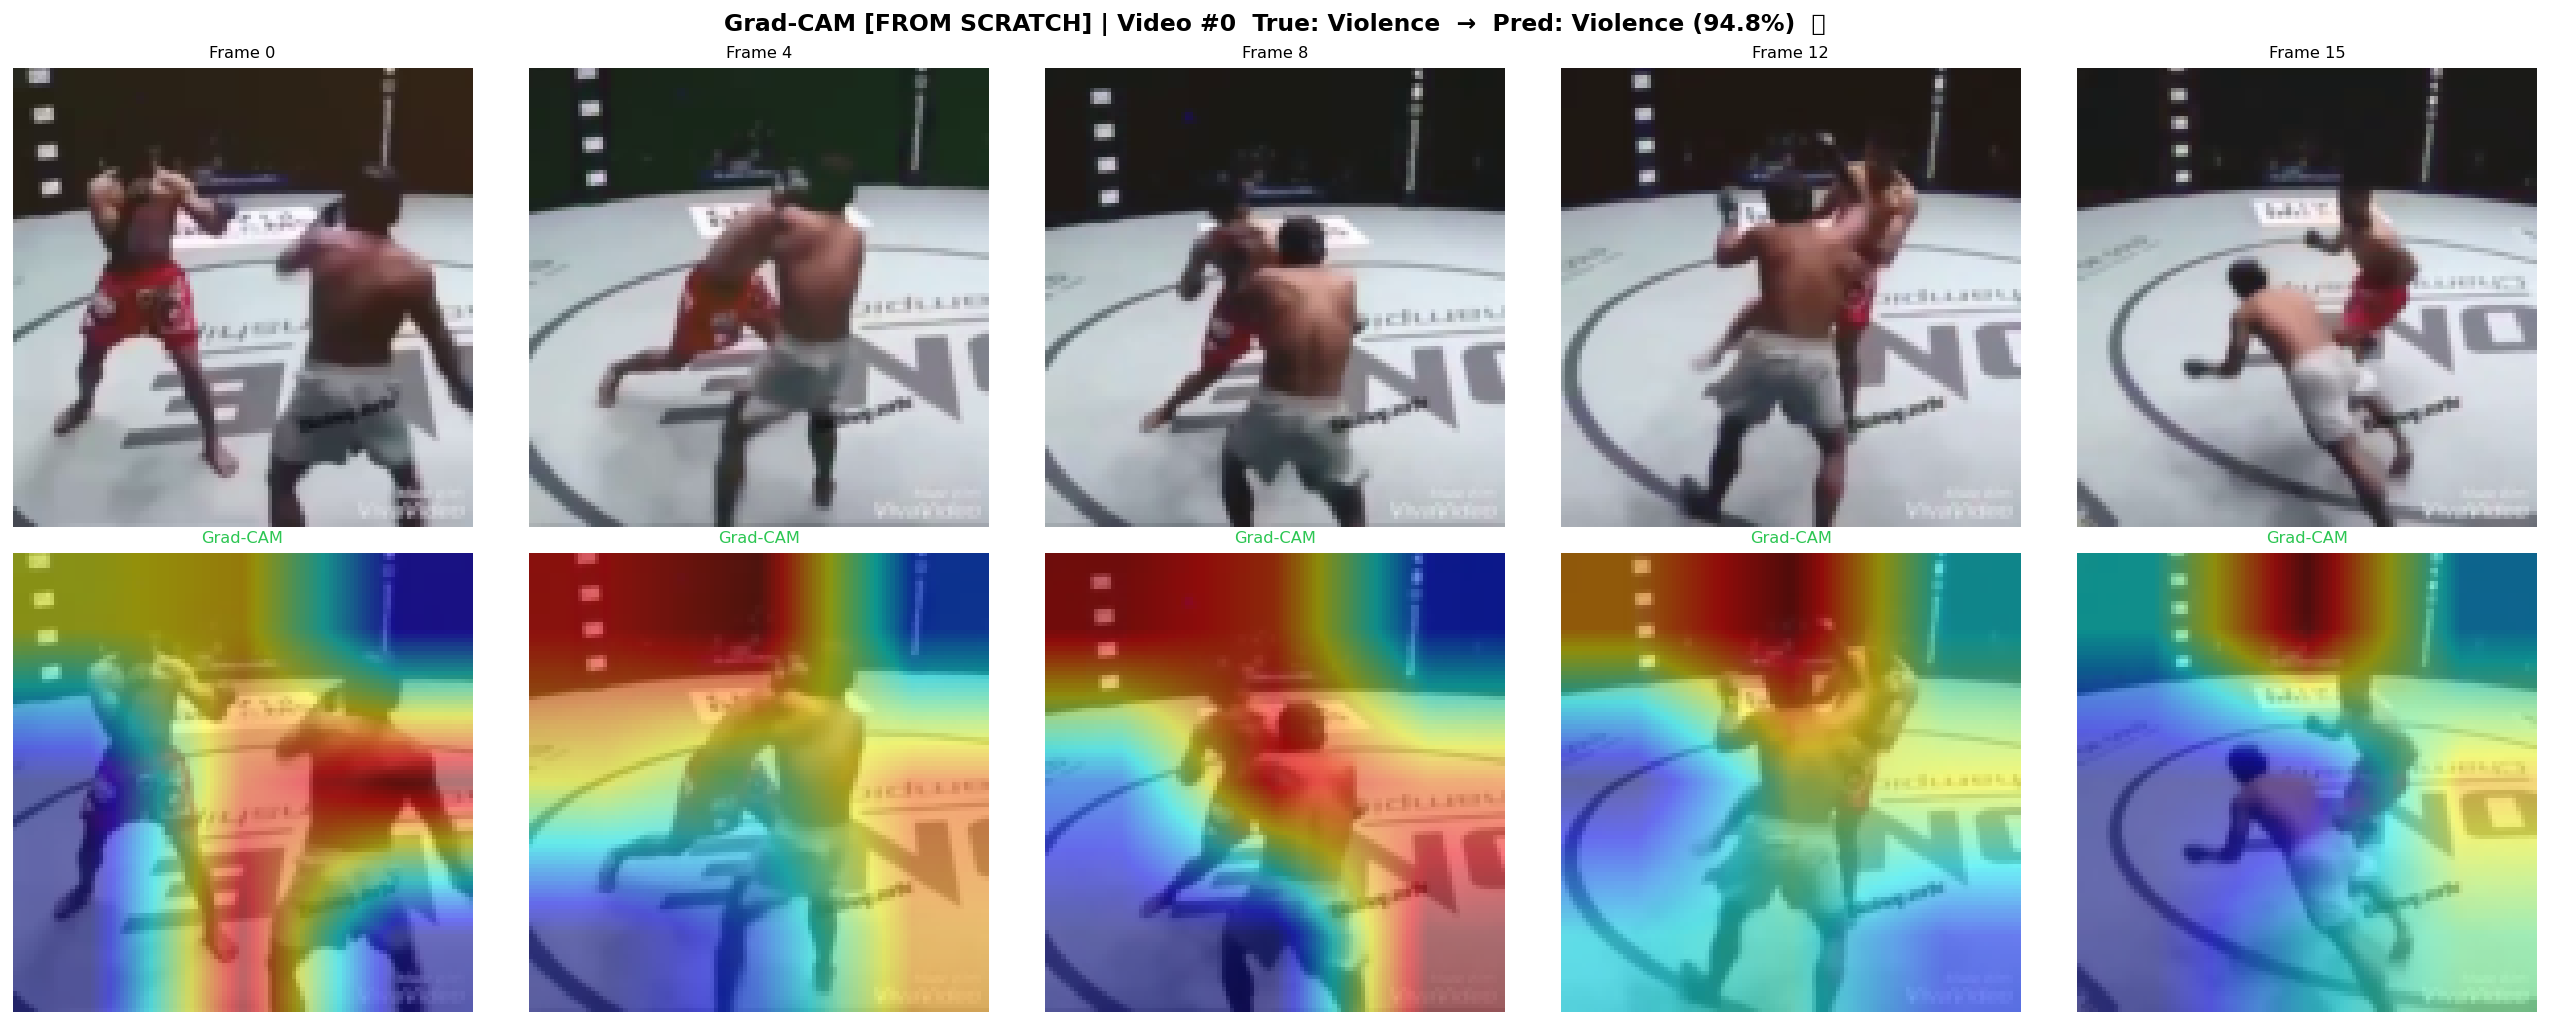

  Video   0 | True=Violence     Pred=Violence     Conf=94.82%  ✅


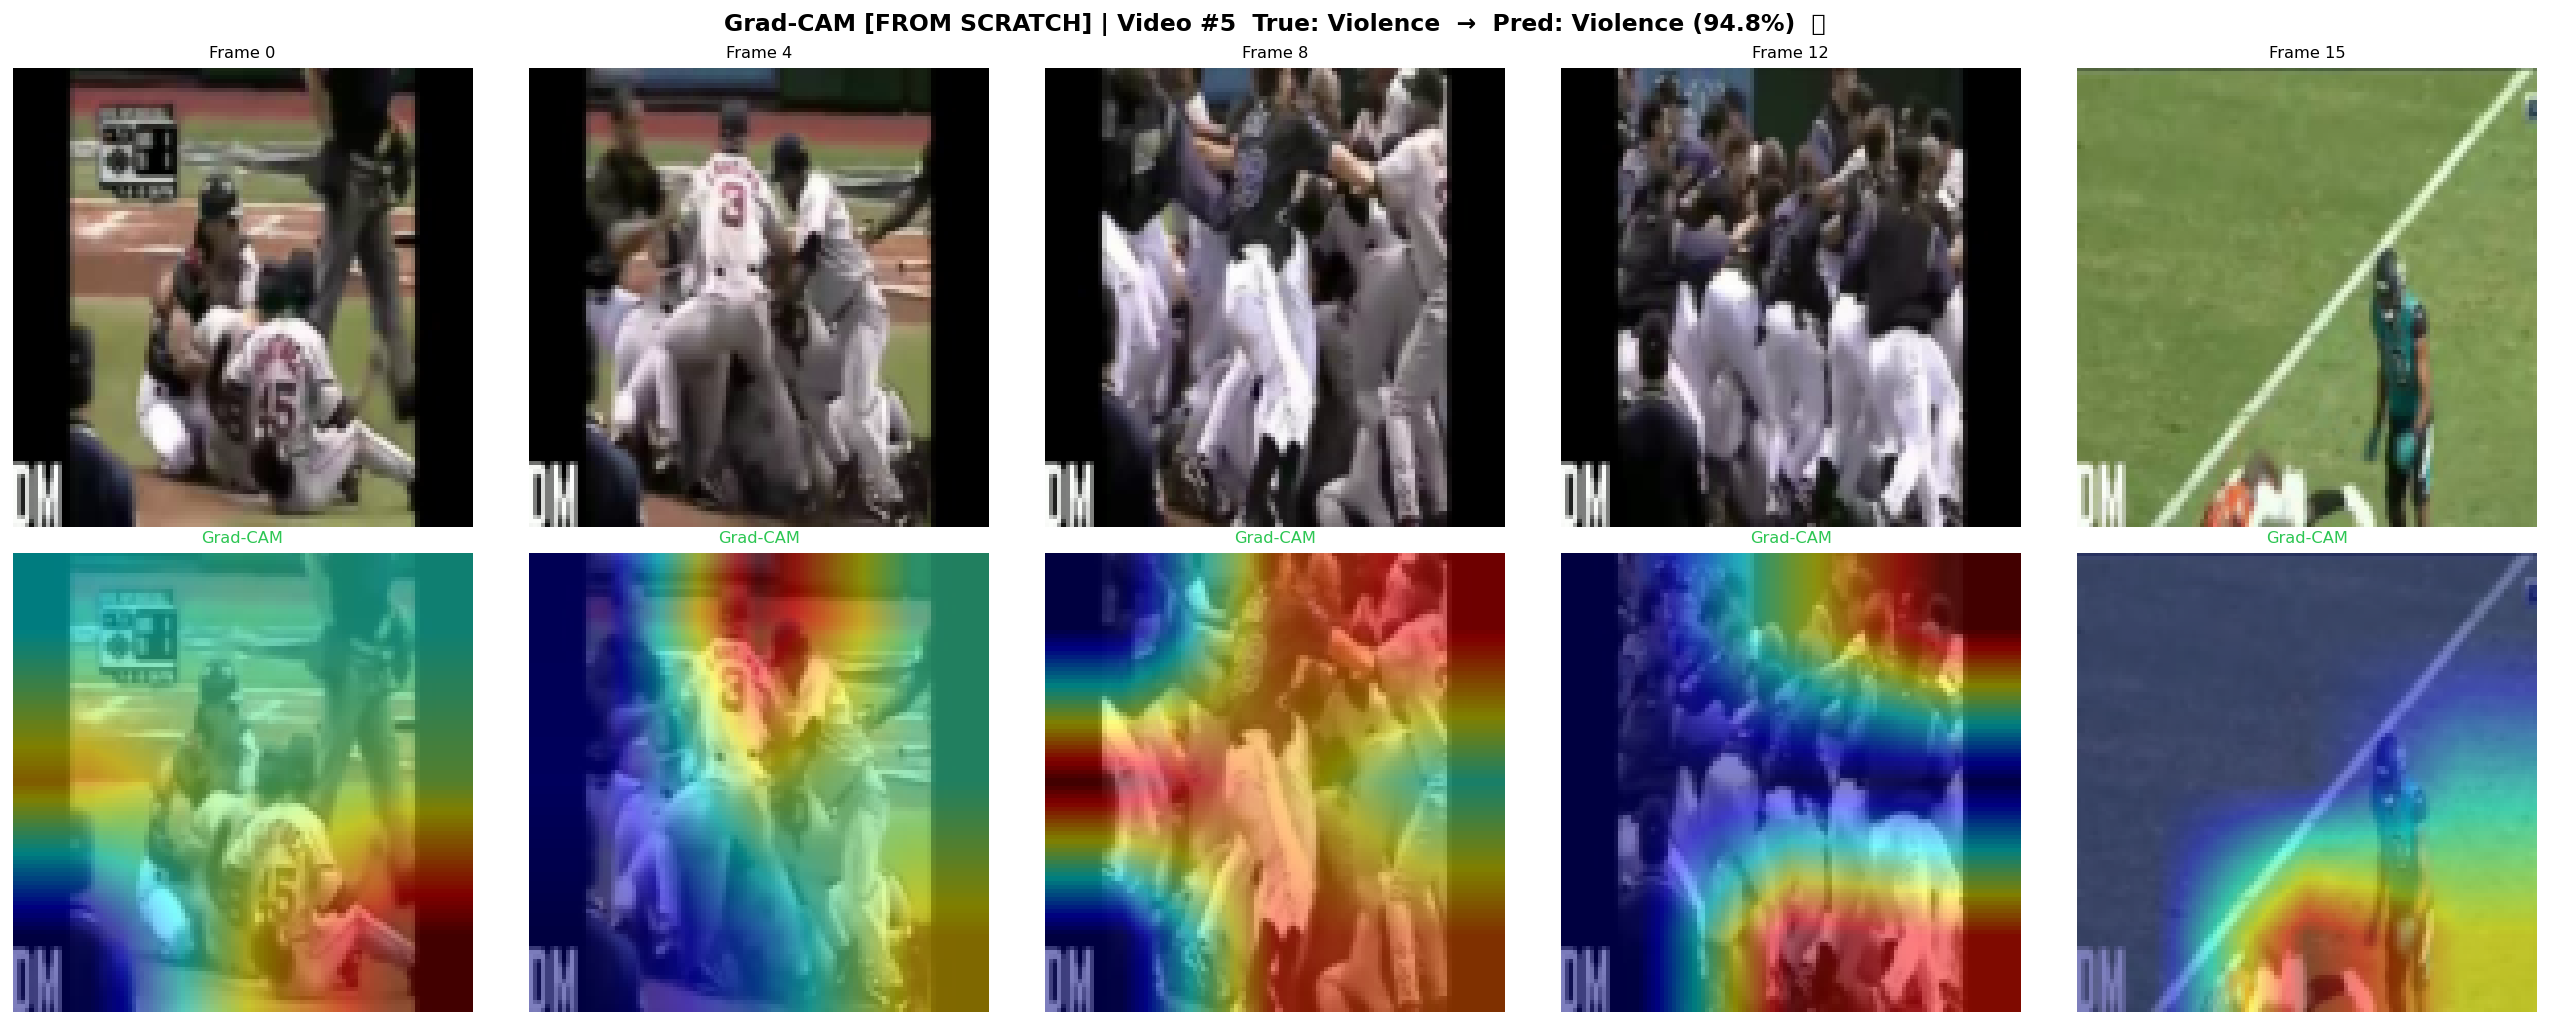

  Video   5 | True=Violence     Pred=Violence     Conf=94.78%  ✅


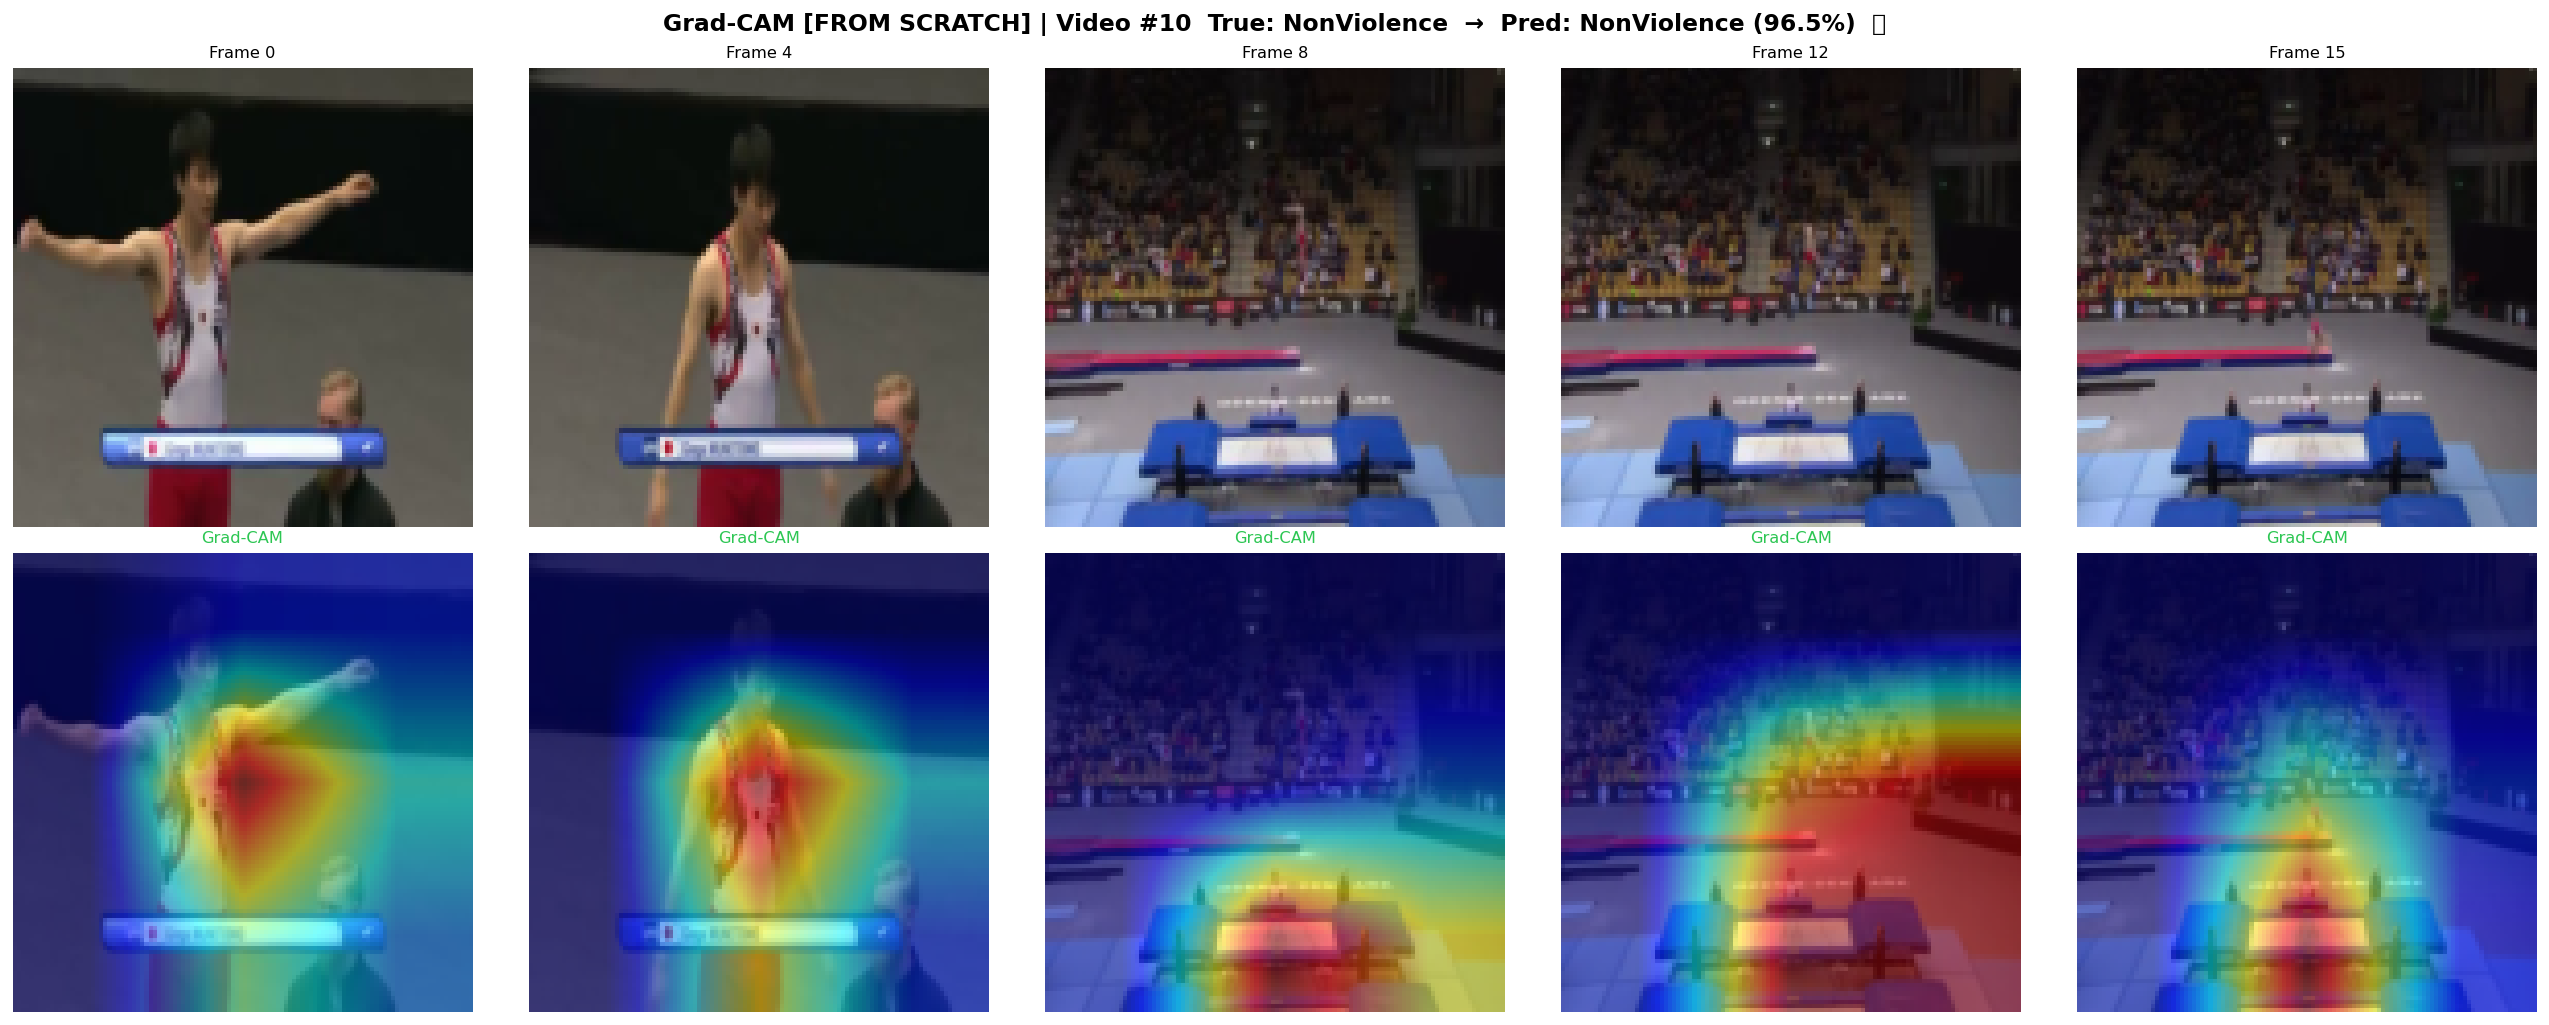

  Video  10 | True=NonViolence  Pred=NonViolence  Conf=96.48%  ✅


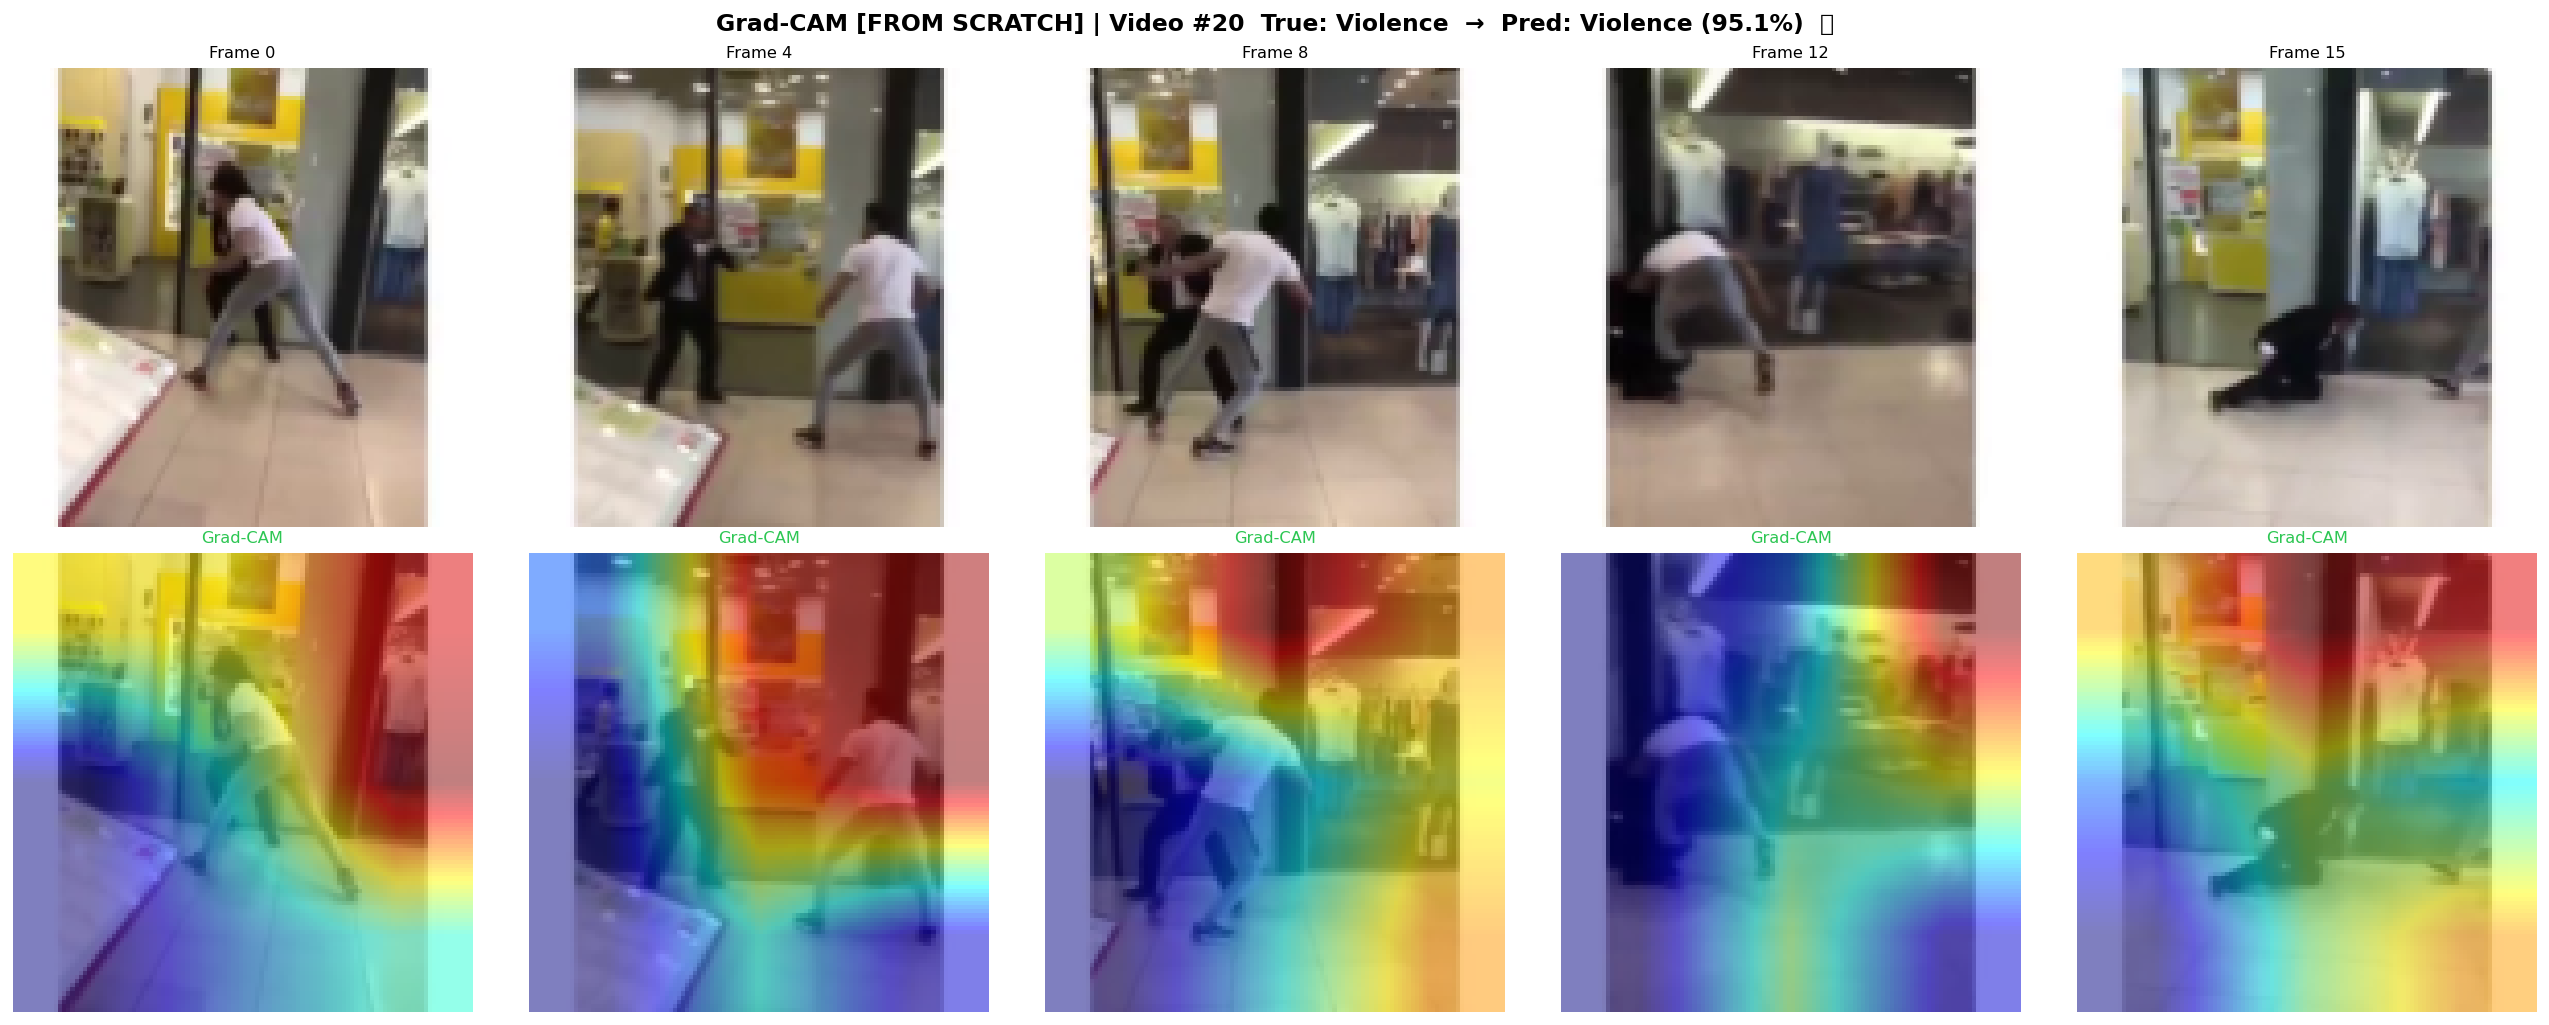

  Video  20 | True=Violence     Pred=Violence     Conf=95.07%  ✅


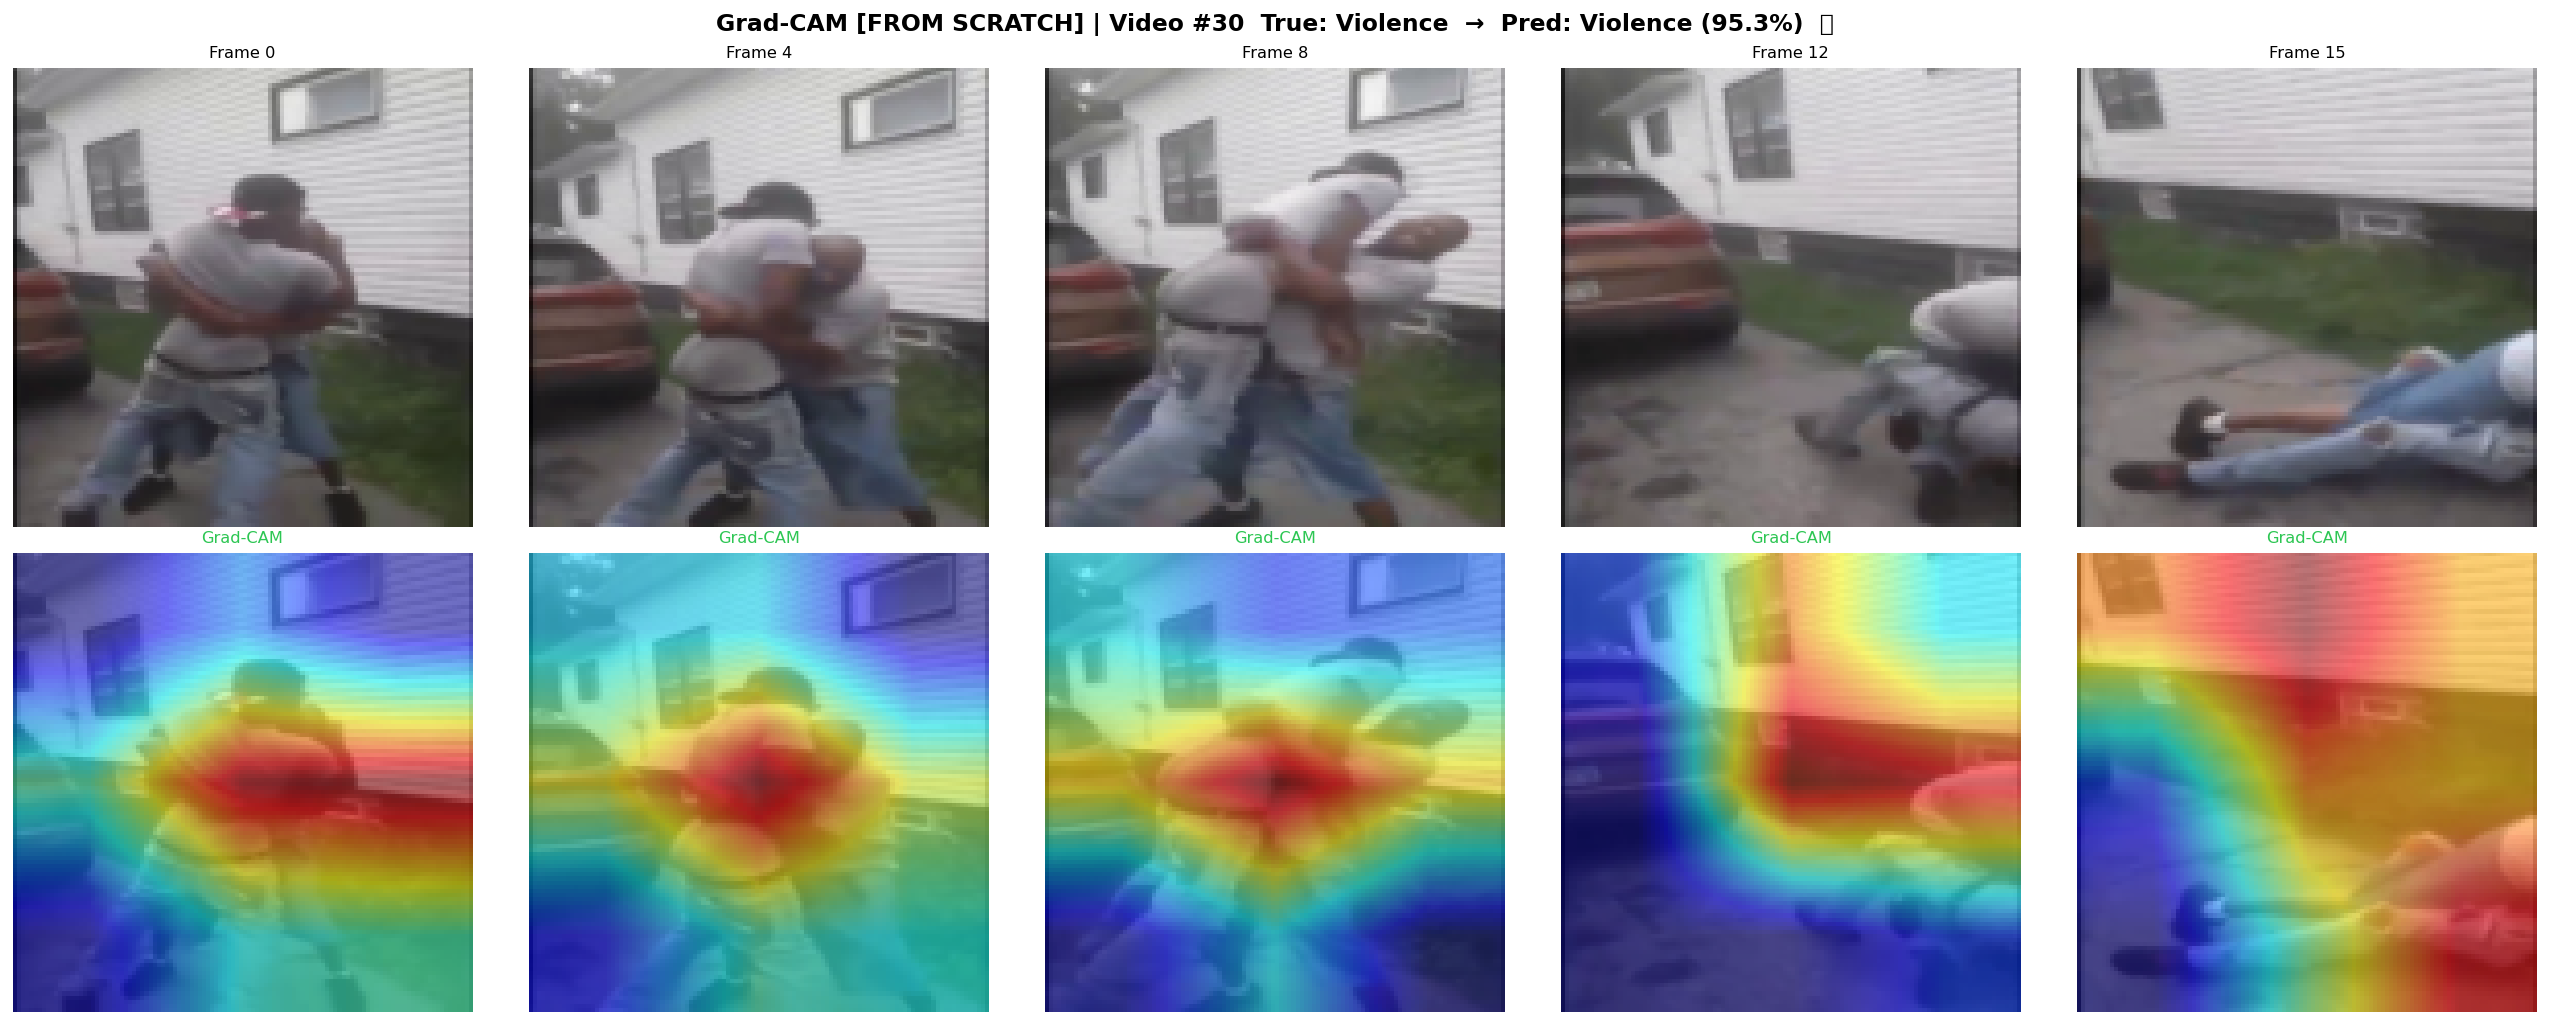

  Video  30 | True=Violence     Pred=Violence     Conf=95.26%  ✅


In [14]:
MEAN_NP = np.array([0.5, 0.5, 0.5])
STD_NP  = np.array([0.5, 0.5, 0.5])

def denormalize(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * STD_NP + MEAN_NP
    return np.clip(img, 0, 1)


def gradcam_video(video_idx, frames_to_show=[0, 4, 8, 12, 15]):
    frames, label = val_ds[video_idx]

    with torch.no_grad():
        inp = frames.unsqueeze(0).to(DEVICE)
        with torch.amp.autocast('cuda'):
            out = model(inp)
    pred = out.argmax(1).item()
    conf = torch.softmax(out, dim=1)[0, pred].item()

    true_name = CFG["classes"][label.item()]
    pred_name = CFG["classes"][pred]
    correct   = "✅" if label.item() == pred else "❌"

    n    = len(frames_to_show)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    fig.suptitle(
        f"Grad-CAM [FROM SCRATCH] | Video #{video_idx}  "
        f"True: {true_name}  →  Pred: {pred_name} ({conf*100:.1f}%)  {correct}",
        fontsize=13, fontweight='bold'
    )

    for col, fi in enumerate(frames_to_show):
        ft            = frames[fi].unsqueeze(0).to(DEVICE)
        grayscale_cam = cam(input_tensor=ft, targets=[ClassifierOutputTarget(pred)])[0]
        rgb_img       = denormalize(frames[fi])
        overlay       = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        axes[0, col].imshow(rgb_img)
        axes[0, col].set_title(f"Frame {fi}", fontsize=9)
        axes[0, col].axis('off')

        axes[1, col].imshow(overlay)
        axes[1, col].set_title("Grad-CAM", fontsize=9, color='#2DC653')
        axes[1, col].axis('off')

    plt.tight_layout()
    return fig, pred_name, true_name, conf, correct


sample_indices = [0, 5, 10, 20, 30]

for idx in sample_indices:
    fig, pred_name, true_name, conf, ok = gradcam_video(idx)
    fig.savefig(f"gradcam_scratch_video_{idx}.png", bbox_inches='tight')
    plt.show()
    print(f"  Video {idx:3d} | True={true_name:12s} Pred={pred_name:12s} Conf={conf:.2%}  {ok}")

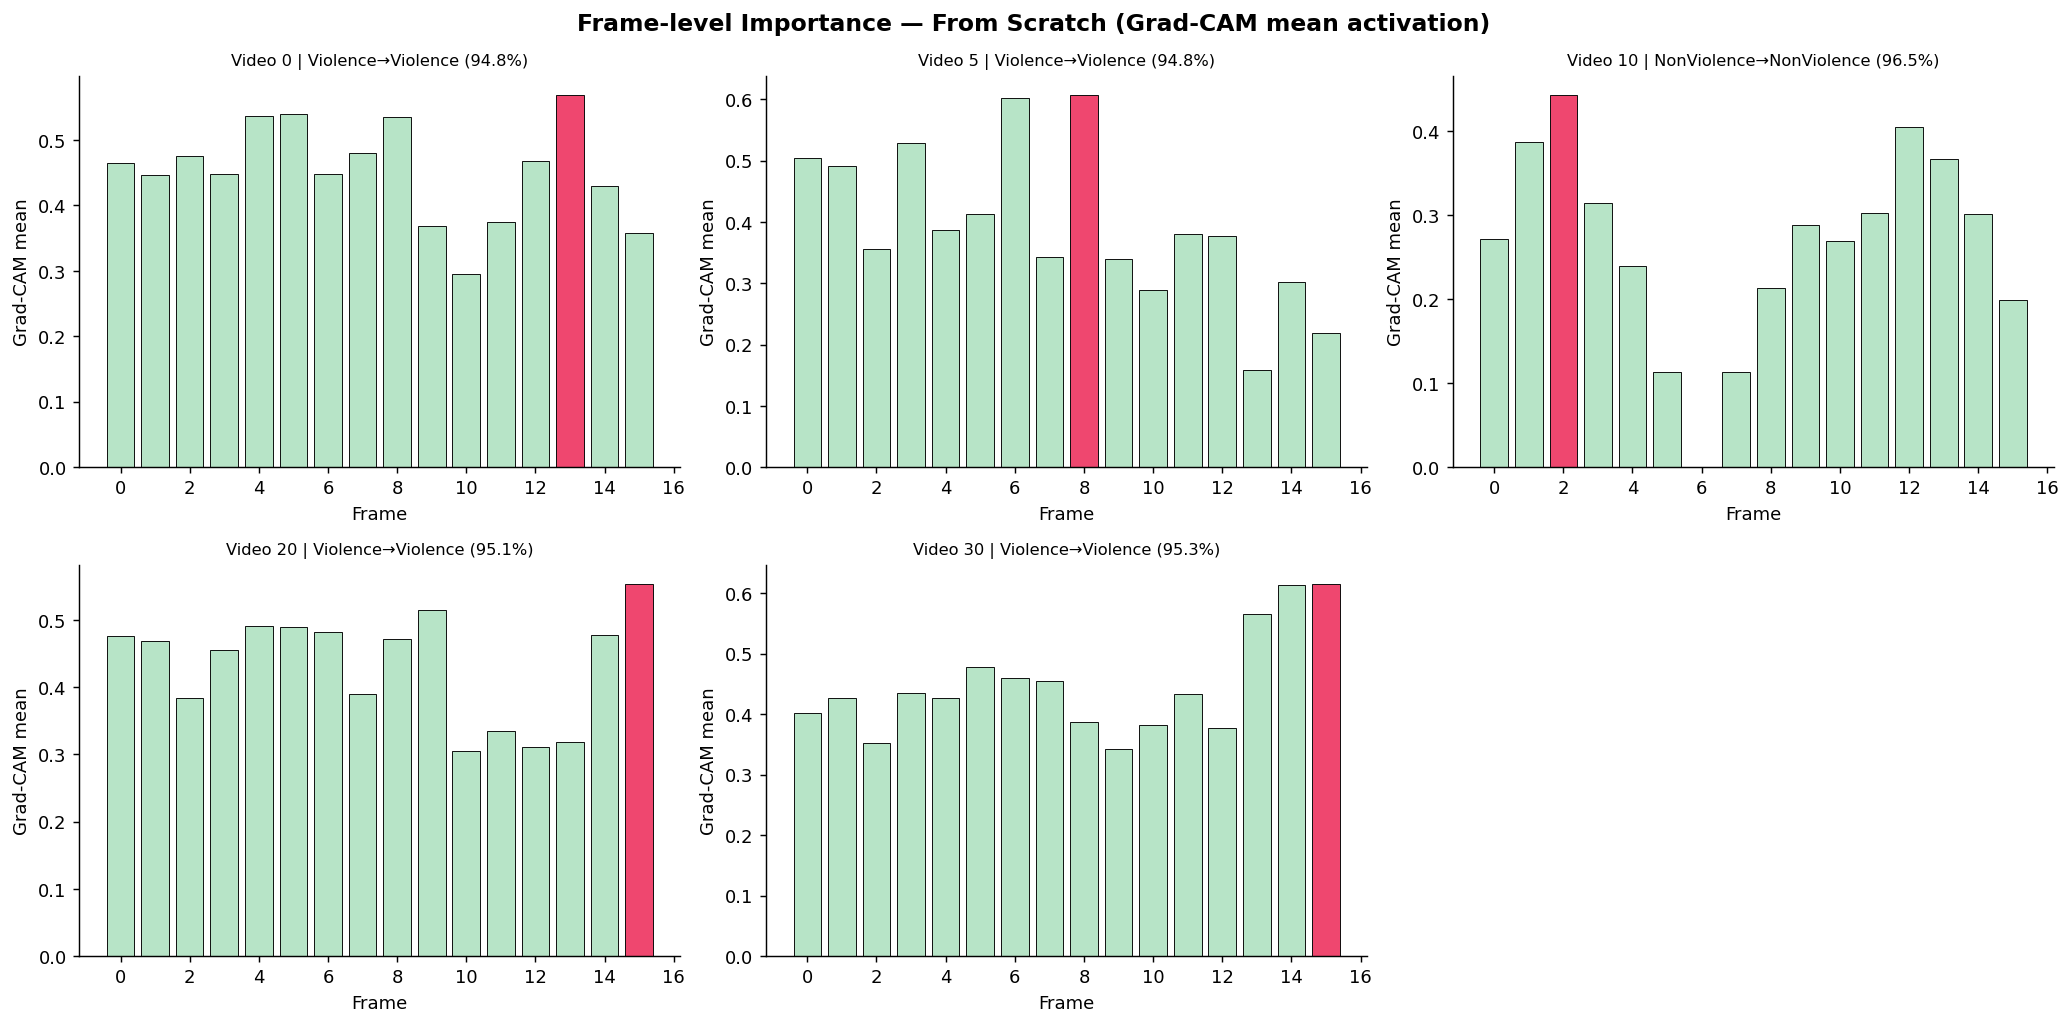

In [15]:
# ══════════════════════════════════════════════════════════════════════════
#  7.2 — Frame Importance Profile
# ══════════════════════════════════════════════════════════════════════════
def frame_importance_profile(video_idx):
    frames, label = val_ds[video_idx]
    with torch.no_grad():
        inp = frames.unsqueeze(0).to(DEVICE)
        with torch.amp.autocast('cuda'):
            out = model(inp)
    pred   = out.argmax(1).item()
    conf   = torch.softmax(out, dim=1)[0, pred].item()
    scores = []
    for fi in range(CFG["num_frames"]):
        ft = frames[fi].unsqueeze(0).to(DEVICE)
        gc = cam(input_tensor=ft, targets=[ClassifierOutputTarget(pred)])[0]
        scores.append(gc.mean())
    return scores, CFG["classes"][label.item()], CFG["classes"][pred], conf


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Frame-level Importance — From Scratch (Grad-CAM mean activation)",
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat[:5]):
    scores, true_name, pred_name, conf = frame_importance_profile(sample_indices[i])
    colors_bar = ['#EF476F' if s == max(scores) else '#B7E4C7' for s in scores]
    ax.bar(range(len(scores)), scores, color=colors_bar, edgecolor='black', linewidth=0.5)
    ax.set_title(f"Video {sample_indices[i]} | {true_name}→{pred_name} ({conf:.1%})", fontsize=9)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Grad-CAM mean")

axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig("gradcam_scratch_frame_importance.png", bbox_inches='tight')
plt.show()

<a id='8'></a>
## 8.  Save Model — model_scratch

In [16]:
save_dict = {
    "model_state_dict" : model.state_dict(),
    "model_class"      : "ViolenceModelScratch",
    "architecture"     : "Custom CNN (5×ConvBlock) + BiGRU — From Scratch",
    "num_frames"       : CFG["num_frames"],
    "img_size"         : CFG["img_size"],
    "classes"          : CFG["classes"],
    "input_size"       : (3, CFG["img_size"], CFG["img_size"]),
    "feature_dim"      : CFG["feature_dim"],
    "pretrained"       : False,
    "best_val_acc"     : best_val_acc,
    "auc_roc"          : float(auc_roc),
    "cfg"              : CFG,
}

torch.save(save_dict, CFG["model_path"])

print("═"*52)
print(f"  ✅ Saved   : {CFG['model_path']}")
print(f"  🔨 Type    : From Scratch (pretrained=False)")
print(f"  🎯 Val Acc : {best_val_acc:.4f}")
print(f"  📈 AUC-ROC : {auc_roc:.4f}")
print("═"*52)

print("""
── Reload snippet ──────────────────────────────────────
  ckpt  = torch.load('model_scratch.pth', map_location='cpu')
  model = ViolenceModelScratch(ckpt['cfg'])
  model.load_state_dict(ckpt['model_state_dict'])
  model.eval()
────────────────────────────────────────────────────────
""")

════════════════════════════════════════════════════
  ✅ Saved   : model_scratch.pth
  🔨 Type    : From Scratch (pretrained=False)
  🎯 Val Acc : 0.9744
  📈 AUC-ROC : 0.9906
════════════════════════════════════════════════════

── Reload snippet ──────────────────────────────────────
  ckpt  = torch.load('model_scratch.pth', map_location='cpu')
  model = ViolenceModelScratch(ckpt['cfg'])
  model.load_state_dict(ckpt['model_state_dict'])
  model.eval()
────────────────────────────────────────────────────────

